# Crop Disease Forecast — Data Understanding
**Mini Project | DS/AIML-A 2026**

This notebook explores the raw climate and disease datasets to understand their structure, size, and key patterns.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nice
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load the Datasets

In [2]:
# Load climate data
df_climate = pd.read_csv('../dataset/raw_data/climate_data.csv', parse_dates=['date'])

# Load disease records
df_disease = pd.read_csv('../dataset/raw_data/disease_records.csv')

print('Climate data shape :', df_climate.shape)
print('Disease data shape :', df_disease.shape)

Climate data shape : (1461, 9)
Disease data shape : (48, 8)


## 3. Preview the Data

In [3]:
print('--- Climate Data (first 5 rows) ---')
df_climate.head()

--- Climate Data (first 5 rows) ---


,date,temp_max,temp_min,rainfall_mm,wind_speed,humidity_max,humidity_min,temp_avg,humidity_avg
0,2020-01-01,29.1,22.5,2.3,15.1,98,69,25.80,83.5
1,2020-01-02,29.6,23.3,1.7,12.0,98,66,26.45,82.0
2,2020-01-03,30.5,23.2,1.9,10.8,99,65,26.85,82.0
3,2020-01-04,30.4,22.4,2.0,10.2,100,70,26.40,85.0
4,2020-01-05,30.0,22.9,1.3,12.3,100,69,26.45,84.5


In [4]:
print('--- Disease Records (first 5 rows) ---')
df_disease.head()

--- Disease Records (first 5 rows) ---


,month,year,month_num,rice_blast,brown_spot,is_monsoon,is_postmonsoon,risk_level
0,2020-01,2020,1,0,0,0,0,Low
1,2020-02,2020,2,0,0,0,0,Low
2,2020-03,2020,3,0,0,0,0,Low
3,2020-04,2020,4,1,0,0,0,Medium
4,2020-05,2020,5,0,0,0,0,Low


## 4. Dataset Info and Data Types

In [5]:
print('=== Climate Data Info ===')
df_climate.info()

=== Climate Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1461 non-null   datetime64[ns]
 1   temp_max      1461 non-null   float64       
 2   temp_min      1461 non-null   float64       
 3   rainfall_mm   1461 non-null   float64       
 4   wind_speed    1461 non-null   float64       
 5   humidity_max  1461 non-null   int64         
 6   humidity_min  1461 non-null   int64         
 7   temp_avg      1461 non-null   float64       
 8   humidity_avg  1461 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(2)
memory usage: 102.9 KB


In [6]:
print('=== Disease Data Info ===')
df_disease.info()

=== Disease Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   month           48 non-null     object
 1   year            48 non-null     int64 
 2   month_num       48 non-null     int64 
 3   rice_blast      48 non-null     int64 
 4   brown_spot      48 non-null     int64 
 5   is_monsoon      48 non-null     int64 
 6   is_postmonsoon  48 non-null     int64 
 7   risk_level      48 non-null     object
dtypes: int64(6), object(2)
memory usage: 3.1+ KB


## 5. Check for Missing Values

In [7]:
print('Missing values in Climate Data:')
print(df_climate.isnull().sum())
print()
print('Missing values in Disease Data:')
print(df_disease.isnull().sum())

Missing values in Climate Data:
date            0
temp_max        0
temp_min        0
rainfall_mm     0
wind_speed      0
humidity_max    0
humidity_min    0
temp_avg        0
humidity_avg    0
dtype: int64

Missing values in Disease Data:
month             0
year              0
month_num         0
rice_blast        0
brown_spot        0
is_monsoon        0
is_postmonsoon    0
risk_level        0
dtype: int64


## 6. Basic Statistics

In [8]:
print('=== Climate Data Statistics ===')
df_climate[['temp_max','temp_min','rainfall_mm','humidity_max','humidity_min','wind_speed']].describe().round(2)

=== Climate Data Statistics ===


,temp_max,temp_min,rainfall_mm,humidity_max,humidity_min,wind_speed
count,1461.00,1461.00,1461.00,1461.00,1461.00,1461.00
mean,33.50,24.08,3.73,90.71,47.63,17.20
std,3.54,2.41,8.12,8.43,14.20,4.08
min,24.20,16.70,0.00,64.00,19.00,5.60
25%,30.50,22.50,0.00,87.00,37.00,14.60
50%,33.80,24.50,0.50,94.00,46.00,16.90
75%,36.20,26.00,3.30,97.00,58.00,19.40
max,42.40,29.30,107.50,100.00,92.00,36.00


## 7. Disease Outbreak Distribution

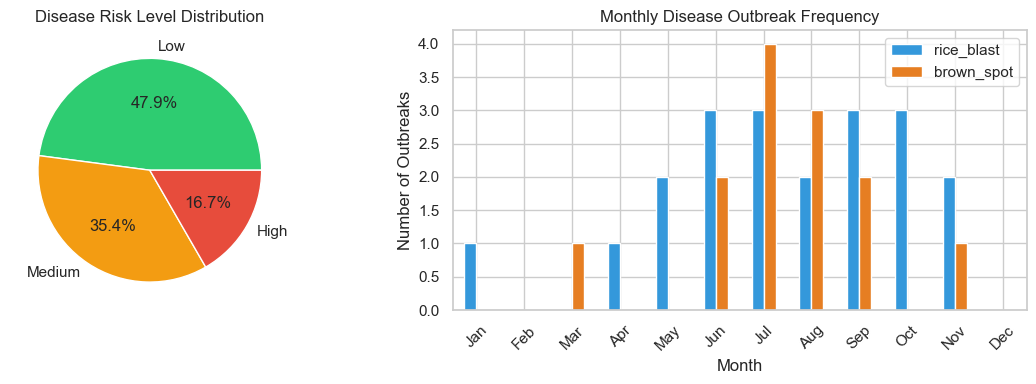

Chart saved to outputs/graphs/disease_distribution.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Risk level pie chart
df_disease['risk_level'].value_counts().plot(
    kind='pie', ax=axes[0], autopct='%1.1f%%',
    colors=['#2ecc71','#f39c12','#e74c3c'],
    title='Disease Risk Level Distribution'
)
axes[0].set_ylabel('')

# Monthly disease frequency bar chart
monthly_counts = df_disease.groupby('month_num')[['rice_blast','brown_spot']].sum()
monthly_counts.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_counts.plot(kind='bar', ax=axes[1], color=['#3498db','#e67e22'])
axes[1].set_title('Monthly Disease Outbreak Frequency')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Outbreaks')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/graphs/disease_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to outputs/graphs/disease_distribution.png')

## 8. Climate Trends Over Time

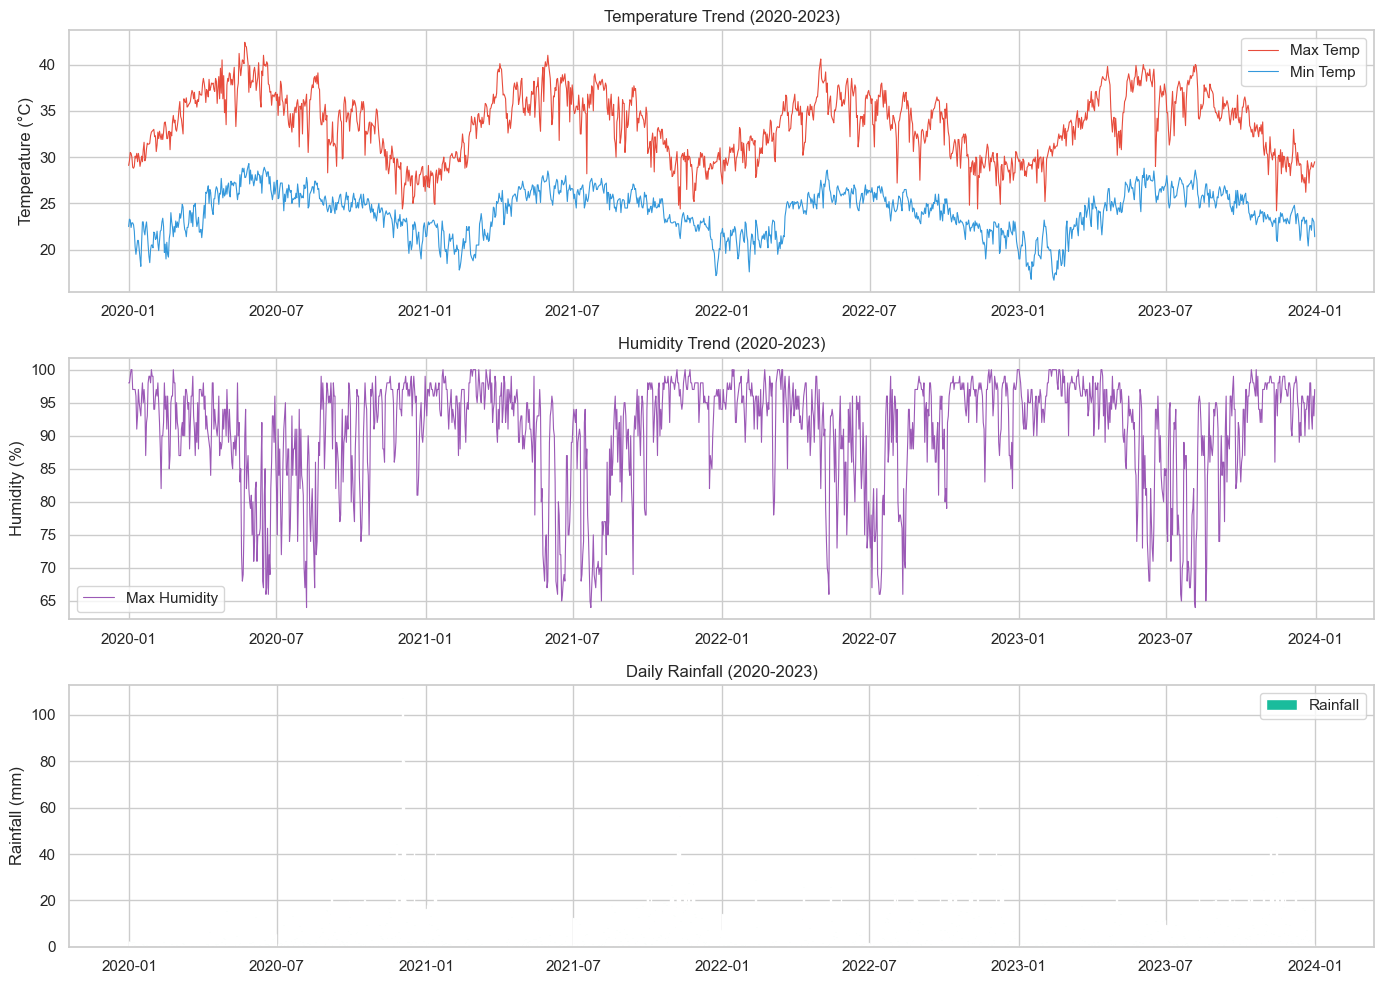

Chart saved to outputs/graphs/climate_trends.png


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Temperature trend
axes[0].plot(df_climate['date'], df_climate['temp_max'], color='#e74c3c', linewidth=0.8, label='Max Temp')
axes[0].plot(df_climate['date'], df_climate['temp_min'], color='#3498db', linewidth=0.8, label='Min Temp')
axes[0].set_title('Temperature Trend (2020-2023)')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()

# Humidity trend
axes[1].plot(df_climate['date'], df_climate['humidity_max'], color='#9b59b6', linewidth=0.8, label='Max Humidity')
axes[1].set_title('Humidity Trend (2020-2023)')
axes[1].set_ylabel('Humidity (%)')
axes[1].legend()

# Rainfall trend
axes[2].bar(df_climate['date'], df_climate['rainfall_mm'], color='#1abc9c', width=1, label='Rainfall')
axes[2].set_title('Daily Rainfall (2020-2023)')
axes[2].set_ylabel('Rainfall (mm)')
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/graphs/climate_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to outputs/graphs/climate_trends.png')

## 9. Key Observations

- The dataset covers **4 years** (2020–2023) of daily climate data for Thanjavur, Tamil Nadu
- **Monsoon months (June–September)** show the highest disease outbreak frequency
- **Humidity above 80%** is strongly associated with Rice Blast outbreaks
- **Rainfall and humidity** are the key climate drivers of crop disease risk
- The dataset is clean with no significant missing values